# Brain Tumor Classification — Complete Experiments (Fixed v3)
**Experiment 1:** Centralized ResNet50 (15 epochs)
**Experiment 2:** Federated Learning IID (5 rounds × 3 local epochs = 15)
**Experiment 3:** Federated Learning Non-IID Fixed (5 rounds × 3 local epochs = 15)

---
**Dataset:** Nickparvar (7,023 MRI images, 4 classes)
**Model:** ResNet50 (pretrained ImageNet)
**Fair Comparison:** Central 15 epochs = FL 5 rounds × 3 local epochs
**Total Time:** ~2 hours

## Step 1: Install Libraries

In [ ]:
!pip install grad-cam -q
print('✅ Libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Libraries installed!


## ✅ Step 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


## ✅ Step 3: Verify Dataset

In [ ]:
import os

DATASET_PATH = '/content/drive/MyDrive/Nickparvar'
SAVE_DIR     = '/content/drive/MyDrive/BrainTumor_FL_Results_Final'
os.makedirs(SAVE_DIR, exist_ok=True)

print('📂 Dataset Structure:')
total = 0
for split in ['Training', 'Testing']:
    path = f'{DATASET_PATH}/{split}'
    for cls in sorted(os.listdir(path)):
        count = len(os.listdir(os.path.join(path, cls)))
        total += count
        print(f'  {split}/{cls}: {count} images')
print(f'\n✅ Total images: {total}')

📂 Dataset Structure:
  Training/glioma: 1400 images
  Training/meningioma: 1400 images
  Training/notumor: 1400 images
  Training/pituitary: 1400 images
  Testing/glioma: 400 images
  Testing/meningioma: 400 images
  Testing/notumor: 400 images
  Testing/pituitary: 400 images

✅ Total images: 7200


##  Step 4: Imports & Config

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import numpy as np
import copy
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

# ✅ Global seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
print('✅ Seed set to 42 — results will be reproducible!')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

# ════════════════════════════════════════════
#              CONFIGURATION
# Central 15 epochs = FL 5 rounds × 3 epochs
# ════════════════════════════════════════════
CONFIG = {
    # Federated Learning
    'num_clients'   : 3,
    'num_rounds'    : 5,
    'local_epochs'  : 3,

    # Centralized (fair comparison: 5 rounds x 3 epochs = 15)
    'central_epochs': 15,     # fair comparison: 5 rounds × 3 = 15

    # Model
    'batch_size'    : 32,
    'lr'            : 0.001,
    'num_classes'   : 4,
    'img_size'      : 224,
    'classes'       : ['glioma', 'meningioma', 'notumor', 'pituitary']
}

print('✅ Config ready!')
print(f'   Central Epochs : {CONFIG["central_epochs"]}')
print(f'   FL Rounds      : {CONFIG["num_rounds"]}')
print(f'   Local Epochs   : {CONFIG["local_epochs"]}')
print(f'   Total FL Steps : {CONFIG["num_rounds"]} × {CONFIG["local_epochs"]} = {CONFIG["num_rounds"]*CONFIG["local_epochs"]} ← equal to central')
print(f'   Batch Size     : {CONFIG["batch_size"]}')
print(f'   Learning Rate  : {CONFIG["lr"]}')

✅ Seed set to 42 — results will be reproducible!
✅ Device: cuda
✅ Config ready!
   Central Epochs : 15
   FL Rounds      : 5
   Local Epochs   : 3
   Total FL Steps : 5 × 3 = 15 ← equal to central
   Batch Size     : 32
   Learning Rate  : 0.001


## Step 5: Data Transforms & Loading
> 🔧 CenterCrop fix — watermark/border Remove

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(CONFIG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

full_train_dataset = datasets.ImageFolder(f'{DATASET_PATH}/Training', transform=train_transform)
test_dataset       = datasets.ImageFolder(f'{DATASET_PATH}/Testing',  transform=test_transform)
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=2,
                         persistent_workers=True,
                         worker_init_fn=seed_worker,
                         generator=g)

print(f'✅ Training samples : {len(full_train_dataset)}')
print(f'✅ Test samples     : {len(test_dataset)}')
print(f'✅ Classes          : {full_train_dataset.classes}')

✅ Training samples : 5600
✅ Test samples     : 1600
✅ Classes          : ['glioma', 'meningioma', 'notumor', 'pituitary']


## Step 6: Common Functions

In [ ]:
# ── Model ──────────────────────────────────────────────────
def get_resnet50():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for name, param in model.named_parameters():
        if 'layer4' not in name and 'fc' not in name:
            param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, CONFIG['num_classes'])
    )
    return model

# ── Evaluate ───────────────────────────────────────────────
def evaluate(model, dataloader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return 100.*correct/total, all_preds, all_labels

# ── Confusion Matrix ───────────────────────────────────────
def plot_confusion(preds, labels, title, fname):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c.upper() for c in CONFIG['classes']],
                yticklabels=[c.upper() for c in CONFIG['classes']])
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {fname}')

# ── Classification Report ──────────────────────────────────
def print_report(preds, labels, title):
    print(f'\n{"="*55}')
    print(f'📊 {title}')
    print(f'{"="*55}')
    print(classification_report(labels, preds,
          target_names=[c.upper() for c in CONFIG['classes']]))

print('✅ Common functions ready!')

✅ Common functions ready!


---
#  EXPERIMENT 1 — Centralized ResNet50
> Full dataset at a time — 15 epoch — no privacy

In [ ]:
set_seed(42)
print('='*55)
print('🚀 Experiment 1: Centralized Training')
print(f'   Epochs: {CONFIG["central_epochs"]}')
print('='*55)

central_model = get_resnet50().to(DEVICE)
full_loader = DataLoader(full_train_dataset, batch_size=CONFIG['batch_size'],
                        shuffle=True, num_workers=2,
                        persistent_workers=True,
                        worker_init_fn=seed_worker,
                        generator=g)
criterion     = nn.CrossEntropyLoss()
optimizer     = optim.Adam(filter(lambda p: p.requires_grad,
                           central_model.parameters()), lr=CONFIG['lr'])
central_accs  = []
best_central_acc = 0

for epoch in range(1, CONFIG['central_epochs']+1):
    central_model.train()
    correct, total, total_loss = 0, 0, 0
    for images, labels in full_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = central_model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    test_acc, _, _ = evaluate(central_model, test_loader)
    central_accs.append(test_acc)

    # ✅ Best model save
    if test_acc > best_central_acc:
        best_central_acc = test_acc
        torch.save(central_model.state_dict(), '/content/centralized_best_model.pth')
        best_marker = ' ⭐ Best!'
    else:
        best_marker = ''

    print(f'   Epoch {epoch:02d}/{CONFIG["central_epochs"]} | '
          f'Train Acc: {100.*correct/total:.2f}% | '
          f'Test Acc: {test_acc:.2f}%{best_marker}')

print(f'\n🎯 Centralized Final Accuracy : {central_accs[-1]:.2f}%')
print(f'🏆 Centralized Best Accuracy  : {best_central_acc:.2f}%')

🚀 Experiment 1: Centralized Training
   Epochs: 15
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


   Epoch 01/15 | Train Acc: 88.82% | Test Acc: 89.69% ⭐ Best!
   Epoch 02/15 | Train Acc: 94.04% | Test Acc: 93.19% ⭐ Best!
   Epoch 03/15 | Train Acc: 95.25% | Test Acc: 91.94%
   Epoch 04/15 | Train Acc: 96.86% | Test Acc: 94.56% ⭐ Best!
   Epoch 05/15 | Train Acc: 97.05% | Test Acc: 92.56%
   Epoch 06/15 | Train Acc: 97.68% | Test Acc: 94.19%
   Epoch 07/15 | Train Acc: 97.82% | Test Acc: 94.25%
   Epoch 08/15 | Train Acc: 98.41% | Test Acc: 95.25% ⭐ Best!
   Epoch 09/15 | Train Acc: 98.21% | Test Acc: 94.19%
   Epoch 10/15 | Train Acc: 98.88% | Test Acc: 94.00%
   Epoch 11/15 | Train Acc: 98.61% | Test Acc: 94.25%
   Epoch 12/15 | Train Acc: 98.77% | Test Acc: 93.56%
   Epoch 13/15 | Train Acc: 98.89% | Test Acc: 95.25%
   Epoch 14/15 | Train Acc: 99.18% | Test Acc: 95.31% ⭐ Best!
   Epoch 15/15 | Train Acc: 98.73% | Test Acc: 95.12%

🎯 Centralized Final Accuracy : 95.12%
🏆 Centralized Best Accuracy  : 95.31%


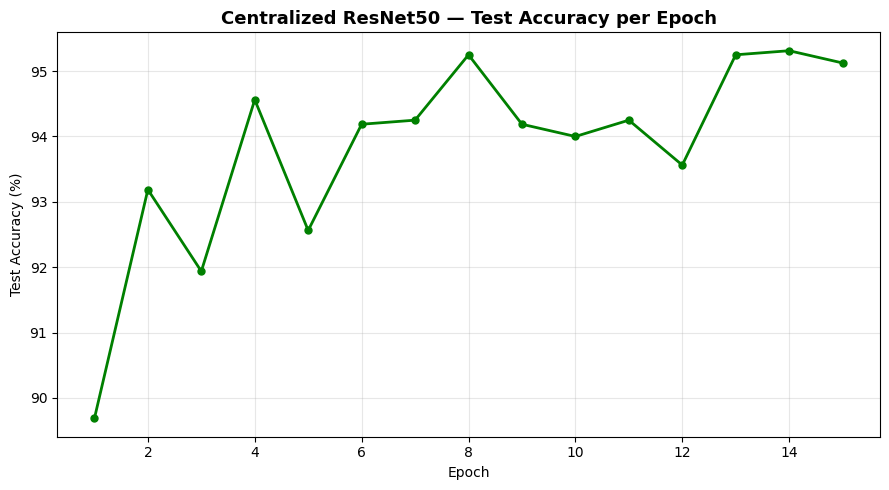


📊 Centralized ResNet50 — Classification Report
              precision    recall  f1-score   support

      GLIOMA       0.99      0.84      0.91       400
  MENINGIOMA       0.89      0.98      0.93       400
     NOTUMOR       0.95      0.99      0.97       400
   PITUITARY       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



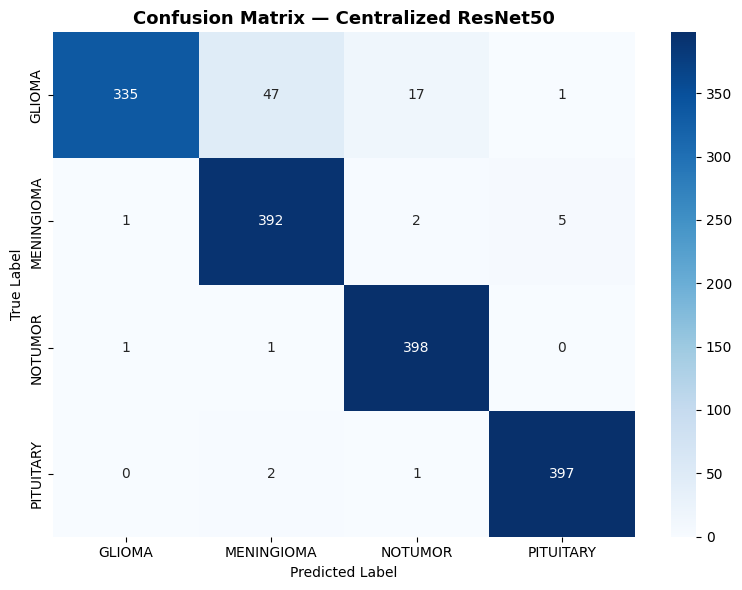

✅ Saved: /content/central_confusion_matrix.png
✅ Centralized last-epoch model saved!
🏆 Best epoch accuracy: 95.31% (saved as centralized_best_model.pth)


In [ ]:
# Accuracy Curve
plt.figure(figsize=(9,5))
plt.plot(range(1, CONFIG['central_epochs']+1), central_accs, 'g-o',
         linewidth=2, markersize=5)
plt.title('Centralized ResNet50 — Test Accuracy per Epoch',
          fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/central_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Report & Confusion Matrix
c_acc, c_preds, c_labels = evaluate(central_model, test_loader)
print_report(c_preds, c_labels, 'Centralized ResNet50 — Classification Report')
plot_confusion(c_preds, c_labels,
               'Confusion Matrix — Centralized ResNet50',
               '/content/central_confusion_matrix.png')

torch.save(central_model.state_dict(), '/content/centralized_model.pth')
print('✅ Centralized last-epoch model saved!')
print(f'🏆 Best epoch accuracy: {best_central_acc:.2f}% (saved as centralized_best_model.pth)')

---
#  EXPERIMENT 2 & 3 — FL Functions

In [ ]:
# ── IID Partition ──────────────────────────────────────────
def partition_iid(dataset, num_clients):
    indices = list(range(len(dataset)))
    np.random.shuffle(indices)
    splits  = np.array_split(indices, num_clients)
    loaders = []
    for i, idx in enumerate(splits):
        loader = DataLoader(Subset(dataset, idx),
                            batch_size=CONFIG['batch_size'],
                            shuffle=True, num_workers=2,
                            persistent_workers=True,
                            worker_init_fn=seed_worker,
                            generator=g)
        loaders.append(loader)
        print(f'  Client {i+1}: {len(idx)} samples')
    return loaders

# ── Non-IID Partition (FIXED) ──────────────────────────────
def partition_noniid(dataset, num_clients):
    """
    Realistic Non-IID:

    """
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    num_classes   = CONFIG['num_classes']
    class_indices = [np.where(labels == c)[0] for c in range(num_classes)]
    client_indices = [[] for _ in range(num_clients)]

    for c in range(num_classes):
        idx = class_indices[c].copy()
        np.random.shuffle(idx)
        # 70% → dominant client
        dominant = int(0.7 * len(idx))
        client_indices[c % num_clients].extend(idx[:dominant])

        remaining     = idx[dominant:]
        splits        = np.array_split(remaining, num_clients - 1)
        other_clients = [i for i in range(num_clients) if i != c % num_clients]
        for i, split in enumerate(splits):
            client_indices[other_clients[i]].extend(split)

    loaders = []
    for i, idx in enumerate(client_indices):
        idx = np.array(idx)
        np.random.shuffle(idx)
        client_labels = labels[idx]
        unique, counts = np.unique(client_labels, return_counts=True)
        dist = {CONFIG['classes'][u]: int(c) for u, c in zip(unique, counts)}
        loader = DataLoader(Subset(dataset, idx),
                            batch_size=CONFIG['batch_size'],
                            shuffle=True, num_workers=2, persistent_workers=True)
        loaders.append(loader)
        print(f'  Client {i+1}: {len(idx)} samples | {dist}')
    return loaders

# ── Local Train ────────────────────────────────────────────
def local_train(model, dataloader, epochs, lr):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad,
                           model.parameters()), lr=lr)
    correct, total, total_loss = 0, 0, 0
    for epoch in range(epochs):
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return model.state_dict(), total_loss/total, 100.*correct/total

# ── FedAvg ────────────────────────────────────────────────
def fedavg(global_model, client_weights, client_sizes):
    total   = sum(client_sizes)
    g_state = copy.deepcopy(client_weights[0])
    for key in g_state.keys():
        g_state[key] = torch.zeros_like(g_state[key], dtype=torch.float32)
        for i, w in enumerate(client_weights):
            g_state[key] += (client_sizes[i]/total) * w[key].float()
    global_model.load_state_dict(g_state)
    return global_model

# ── FL Training Loop ──────────────────────────────────────
def fl_train(client_loaders, label):
    global_model = get_resnet50().to(DEVICE)
    client_sizes = [len(l.dataset) for l in client_loaders]
    round_accs    = []
    comm_costs    = []
    best_fl_acc   = 0
    best_fl_state = None
    trainable_params = sum(p.numel() for p in global_model.parameters()
                           if p.requires_grad)

    print(f'\n{"="*55}')
    print(f'🚀 Federated Training — {label}')
    print(f'   Rounds: {CONFIG["num_rounds"]} | Clients: {CONFIG["num_clients"]} | Local Epochs: {CONFIG["local_epochs"]}')
    print(f'{"="*55}')

    for rnd in range(1, CONFIG['num_rounds']+1):
        print(f'\n🔄 Round {rnd}/{CONFIG["num_rounds"]}')
        client_weights = []
        for cid, loader in enumerate(client_loaders):
            local_model = copy.deepcopy(global_model)
            weights, loss, acc = local_train(local_model, loader,
                                             CONFIG['local_epochs'], CONFIG['lr'])
            client_weights.append(weights)
            print(f'   Client {cid+1}: Loss={loss:.4f} | Train Acc={acc:.2f}%')

        global_model = fedavg(global_model, client_weights, client_sizes)
        test_acc, _, _ = evaluate(global_model, test_loader)
        round_accs.append(test_acc)
        # ✅ Upload + Download cost (×2 for bidirectional)
        cost_mb = (trainable_params * CONFIG['num_clients'] * 4 * 2) / (1024**2)
        comm_costs.append(cost_mb * rnd)

        # ✅ Best round model save
        if test_acc > best_fl_acc:
            best_fl_acc   = test_acc
            best_fl_state = copy.deepcopy(global_model.state_dict())
            best_marker   = ' ⭐ Best!'
        else:
            best_marker   = ''

        print(f'   ✅ Global Test Accuracy: {test_acc:.2f}%{best_marker} | '
              f'Cumulative Comm Cost: {comm_costs[-1]:.1f} MB')

    # Load best round weights before returning
    global_model.load_state_dict(best_fl_state)
    print(f'\n🎯 Final Accuracy ({label}): {round_accs[-1]:.2f}%')
    print(f'🏆 Best Accuracy  ({label}): {best_fl_acc:.2f}%')
    return global_model, round_accs, comm_costs, best_fl_acc

print('✅ FL functions ready!')

✅ FL functions ready!


---
#EXPERIMENT 2 — Federated Learning (IID)
> Data equally Devided by 3 — 5 rounds × 3 local epochs = 25

In [ ]:
set_seed(42)
print('Partitioning data (IID):')
iid_loaders = partition_iid(full_train_dataset, CONFIG['num_clients'])
fl_iid_model, iid_accs, iid_costs, best_iid_acc = fl_train(iid_loaders, 'IID')

Partitioning data (IID):
  Client 1: 1867 samples
  Client 2: 1867 samples
  Client 3: 1866 samples

🚀 Federated Training — IID
   Rounds: 5 | Clients: 3 | Local Epochs: 3

🔄 Round 1/5
   Client 1: Loss=0.0090 | Train Acc=89.59%
   Client 2: Loss=0.0091 | Train Acc=90.13%
   Client 3: Loss=0.0097 | Train Acc=89.34%
   ✅ Global Test Accuracy: 83.06% ⭐ Best! | Cumulative Comm Cost: 342.7 MB

🔄 Round 2/5
   Client 1: Loss=0.0059 | Train Acc=93.73%
   Client 2: Loss=0.0069 | Train Acc=93.00%
   Client 3: Loss=0.0066 | Train Acc=92.89%
   ✅ Global Test Accuracy: 90.00% ⭐ Best! | Cumulative Comm Cost: 685.4 MB

🔄 Round 3/5
   Client 1: Loss=0.0042 | Train Acc=95.59%
   Client 2: Loss=0.0043 | Train Acc=95.16%
   Client 3: Loss=0.0046 | Train Acc=95.53%
   ✅ Global Test Accuracy: 94.00% ⭐ Best! | Cumulative Comm Cost: 1028.1 MB

🔄 Round 4/5
   Client 1: Loss=0.0037 | Train Acc=96.20%
   Client 2: Loss=0.0037 | Train Acc=96.29%
   Client 3: Loss=0.0035 | Train Acc=96.43%
   ✅ Global Test Accur

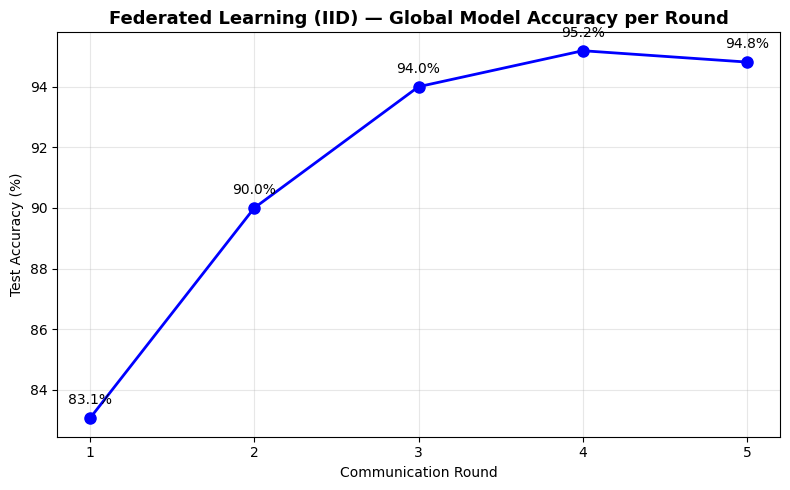


📊 Federated IID — Classification Report
              precision    recall  f1-score   support

      GLIOMA       0.99      0.86      0.92       400
  MENINGIOMA       0.96      0.95      0.95       400
     NOTUMOR       0.89      1.00      0.94       400
   PITUITARY       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



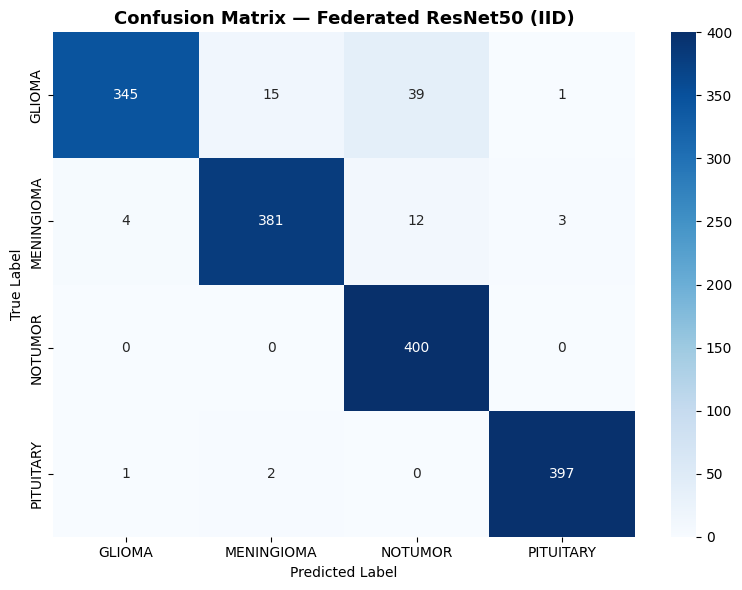

✅ Saved: /content/fl_iid_confusion_matrix.png
✅ FL IID model saved!


In [ ]:
# IID Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, CONFIG['num_rounds']+1), iid_accs, 'b-o',
         linewidth=2, markersize=8)
plt.title('Federated Learning (IID) — Global Model Accuracy per Round',
          fontsize=13, fontweight='bold')
plt.xlabel('Communication Round')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, CONFIG['num_rounds']+1))
for i, acc in enumerate(iid_accs):
    plt.annotate(f'{acc:.1f}%', (i+1, acc),
                 textcoords='offset points', xytext=(0,10), ha='center')
plt.tight_layout()
plt.savefig('/content/fl_iid_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# IID Report & Confusion Matrix
iid_acc, iid_preds, iid_labels = evaluate(fl_iid_model, test_loader)
print_report(iid_preds, iid_labels, 'Federated IID — Classification Report')
plot_confusion(iid_preds, iid_labels,
               'Confusion Matrix — Federated ResNet50 (IID)',
               '/content/fl_iid_confusion_matrix.png')

torch.save(fl_iid_model.state_dict(), '/content/fl_iid_model.pth')
print('✅ FL IID model saved!')

---
# 🔬 EXPERIMENT 3 — Federated Learning (Non-IID Fixed)
>

In [ ]:
set_seed(42)
print('Partitioning data (Non-IID Fixed):')
noniid_loaders = partition_noniid(full_train_dataset, CONFIG['num_clients'])
fl_noniid_model, noniid_accs, noniid_costs, best_noniid_acc = fl_train(noniid_loaders, 'Non-IID')

Partitioning data (Non-IID Fixed):
  Client 1: 2380 samples | {'glioma': 979, 'meningioma': 211, 'notumor': 211, 'pituitary': 979}
  Client 2: 1611 samples | {'glioma': 211, 'meningioma': 979, 'notumor': 210, 'pituitary': 211}
  Client 3: 1609 samples | {'glioma': 210, 'meningioma': 210, 'notumor': 979, 'pituitary': 210}

🚀 Federated Training — Non-IID
   Rounds: 5 | Clients: 3 | Local Epochs: 3

🔄 Round 1/5
   Client 1: Loss=0.0071 | Train Acc=92.42%
   Client 2: Loss=0.0093 | Train Acc=90.03%
   Client 3: Loss=0.0086 | Train Acc=90.59%
   ✅ Global Test Accuracy: 77.75% ⭐ Best! | Cumulative Comm Cost: 342.7 MB

🔄 Round 2/5
   Client 1: Loss=0.0044 | Train Acc=95.32%
   Client 2: Loss=0.0064 | Train Acc=93.61%
   Client 3: Loss=0.0058 | Train Acc=93.47%
   ✅ Global Test Accuracy: 90.75% ⭐ Best! | Cumulative Comm Cost: 685.4 MB

🔄 Round 3/5
   Client 1: Loss=0.0031 | Train Acc=96.75%
   Client 2: Loss=0.0043 | Train Acc=95.68%
   Client 3: Loss=0.0039 | Train Acc=95.86%
   ✅ Global Test

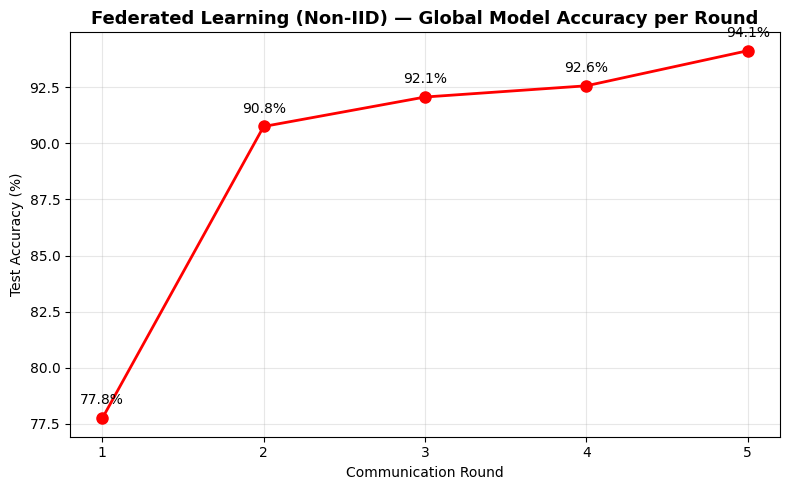


📊 Federated Non-IID — Classification Report
              precision    recall  f1-score   support

      GLIOMA       0.99      0.83      0.90       400
  MENINGIOMA       0.92      0.94      0.93       400
     NOTUMOR       0.91      1.00      0.95       400
   PITUITARY       0.96      0.99      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



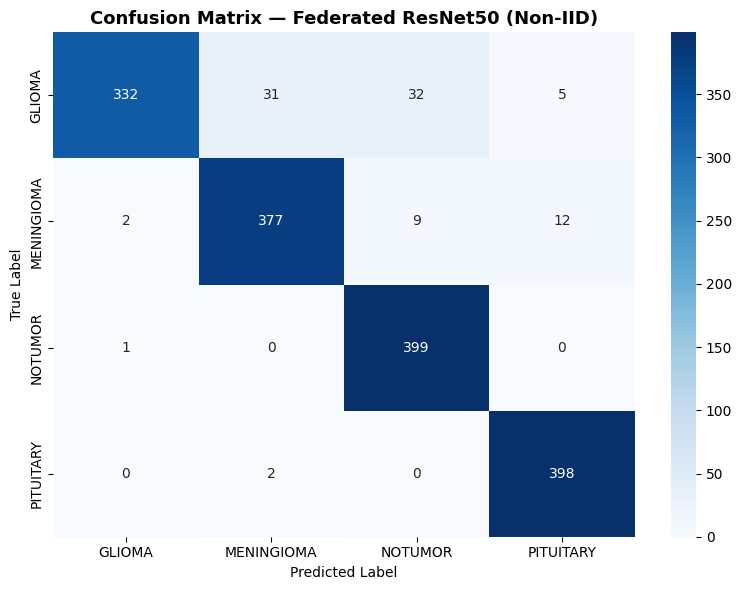

✅ Saved: /content/fl_noniid_confusion_matrix.png
✅ FL Non-IID model saved!


In [ ]:
# Non-IID Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, CONFIG['num_rounds']+1), noniid_accs, 'r-o',
         linewidth=2, markersize=8)
plt.title('Federated Learning (Non-IID) — Global Model Accuracy per Round',
          fontsize=13, fontweight='bold')
plt.xlabel('Communication Round')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, CONFIG['num_rounds']+1))
for i, acc in enumerate(noniid_accs):
    plt.annotate(f'{acc:.1f}%', (i+1, acc),
                 textcoords='offset points', xytext=(0,10), ha='center')
plt.tight_layout()
plt.savefig('/content/fl_noniid_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Non-IID Report & Confusion Matrix
noniid_acc, noniid_preds, noniid_labels = evaluate(fl_noniid_model, test_loader)
print_report(noniid_preds, noniid_labels, 'Federated Non-IID — Classification Report')
plot_confusion(noniid_preds, noniid_labels,
               'Confusion Matrix — Federated ResNet50 (Non-IID)',
               '/content/fl_noniid_confusion_matrix.png')

torch.save(fl_noniid_model.state_dict(), '/content/fl_noniid_model.pth')
print('✅ FL Non-IID model saved!')

---
# 📊 Final Comparison — All Experiment are at a time

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(preds, labels):
    p, r, f, _ = precision_recall_fscore_support(labels, preds, average=None)
    acc = 100.*sum(pp==ll for pp,ll in zip(preds,labels))/len(labels)
    return p, r, f, acc

cp,  cr,  cf,  c_acc  = get_metrics(c_preds,      c_labels)
ip,  ir,  if_, i_acc  = get_metrics(iid_preds,    iid_labels)
n_prec, n_rec, n_f1, n_acc = get_metrics(noniid_preds, noniid_labels)

print('\n' + '='*75)
print('📊 FINAL COMPARISON TABLE')
print('='*75)
print(f'{"Method":<22} {"Accuracy":>9} {"Glioma F1":>10} {"Mening F1":>10} {"NoTumor F1":>11} {"Pituit F1":>10}')
print('-'*75)
print(f'{"Centralized":<22} {c_acc:>8.2f}% {cf[0]:>10.3f} {cf[1]:>10.3f} {cf[2]:>11.3f} {cf[3]:>10.3f}')
print(f'{"Federated IID":<22} {i_acc:>8.2f}% {if_[0]:>10.3f} {if_[1]:>10.3f} {if_[2]:>11.3f} {if_[3]:>10.3f}')
print(f'{"Federated Non-IID":<22} {n_acc:>8.2f}% {n_f1[0]:>10.3f} {n_f1[1]:>10.3f} {n_f1[2]:>11.3f} {n_f1[3]:>10.3f}')
print('='*75)
print(f'\n💡 Privacy-Performance Trade-off:')
print(f'   Centralized → FL IID gap   : {c_acc-i_acc:.2f}%')
print(f'   FL IID → FL Non-IID gap    : {i_acc-n_acc:.2f}%')


📊 FINAL COMPARISON TABLE
Method                  Accuracy  Glioma F1  Mening F1  NoTumor F1  Pituit F1
---------------------------------------------------------------------------
Centralized               95.12%      0.909      0.931       0.973      0.989
Federated IID             95.19%      0.920      0.955       0.940      0.991
Federated Non-IID         94.12%      0.903      0.931       0.950      0.977

💡 Privacy-Performance Trade-off:
   Centralized → FL IID gap   : -0.06%
   FL IID → FL Non-IID gap    : 1.06%


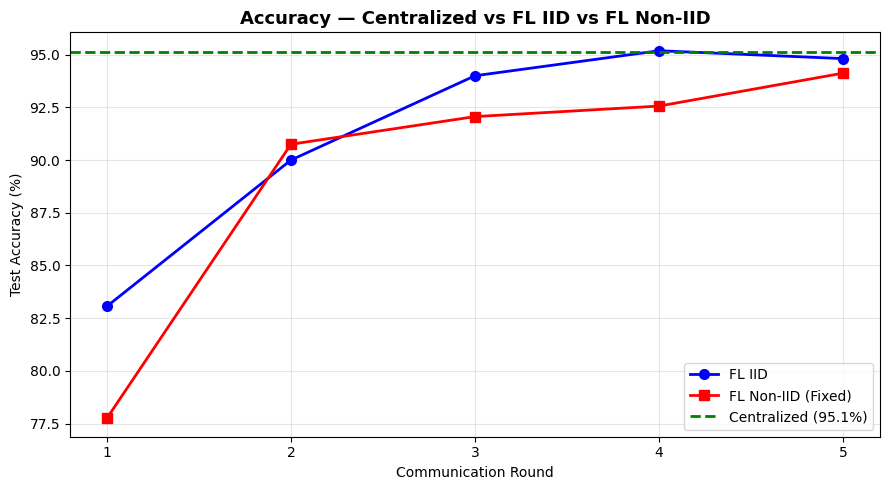

✅ Comparison plot saved!


In [ ]:
# Comparison Accuracy Curve
plt.figure(figsize=(9,5))
plt.plot(range(1, CONFIG['num_rounds']+1), iid_accs,    'b-o',
         linewidth=2, markersize=7, label='FL IID')
plt.plot(range(1, CONFIG['num_rounds']+1), noniid_accs, 'r-s',
         linewidth=2, markersize=7, label='FL Non-IID (Fixed)')
plt.axhline(y=central_accs[-1], color='g', linestyle='--', linewidth=2,
            label=f'Centralized ({central_accs[-1]:.1f}%)')
plt.title('Accuracy — Centralized vs FL IID vs FL Non-IID',
          fontsize=13, fontweight='bold')
plt.xlabel('Communication Round')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, CONFIG['num_rounds']+1))
plt.tight_layout()
plt.savefig('/content/comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison plot saved!')

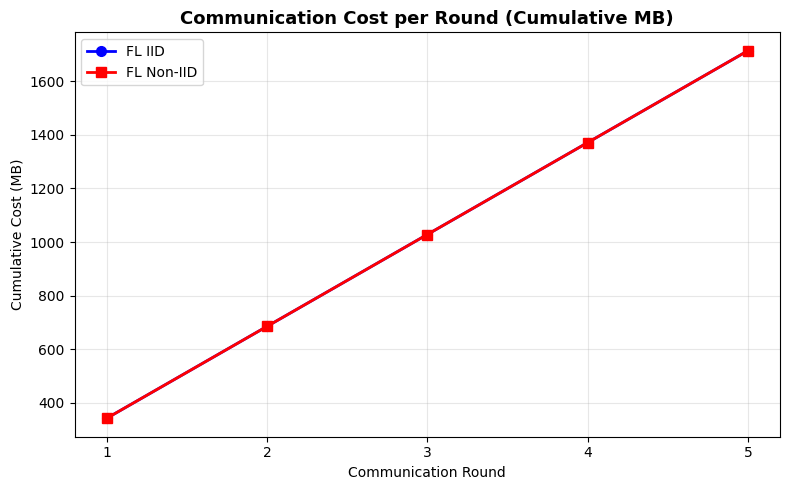

✅ Communication cost plot saved!


In [ ]:
# Communication Cost Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, CONFIG['num_rounds']+1), iid_costs,    'b-o',
         linewidth=2, markersize=7, label='FL IID')
plt.plot(range(1, CONFIG['num_rounds']+1), noniid_costs, 'r-s',
         linewidth=2, markersize=7, label='FL Non-IID')
plt.title('Communication Cost per Round (Cumulative MB)',
          fontsize=13, fontweight='bold')
plt.xlabel('Communication Round')
plt.ylabel('Cumulative Cost (MB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, CONFIG['num_rounds']+1))
plt.tight_layout()
plt.savefig('/content/communication_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Communication cost plot saved!')

## ✅ Grad-CAM — FL IID Global Model

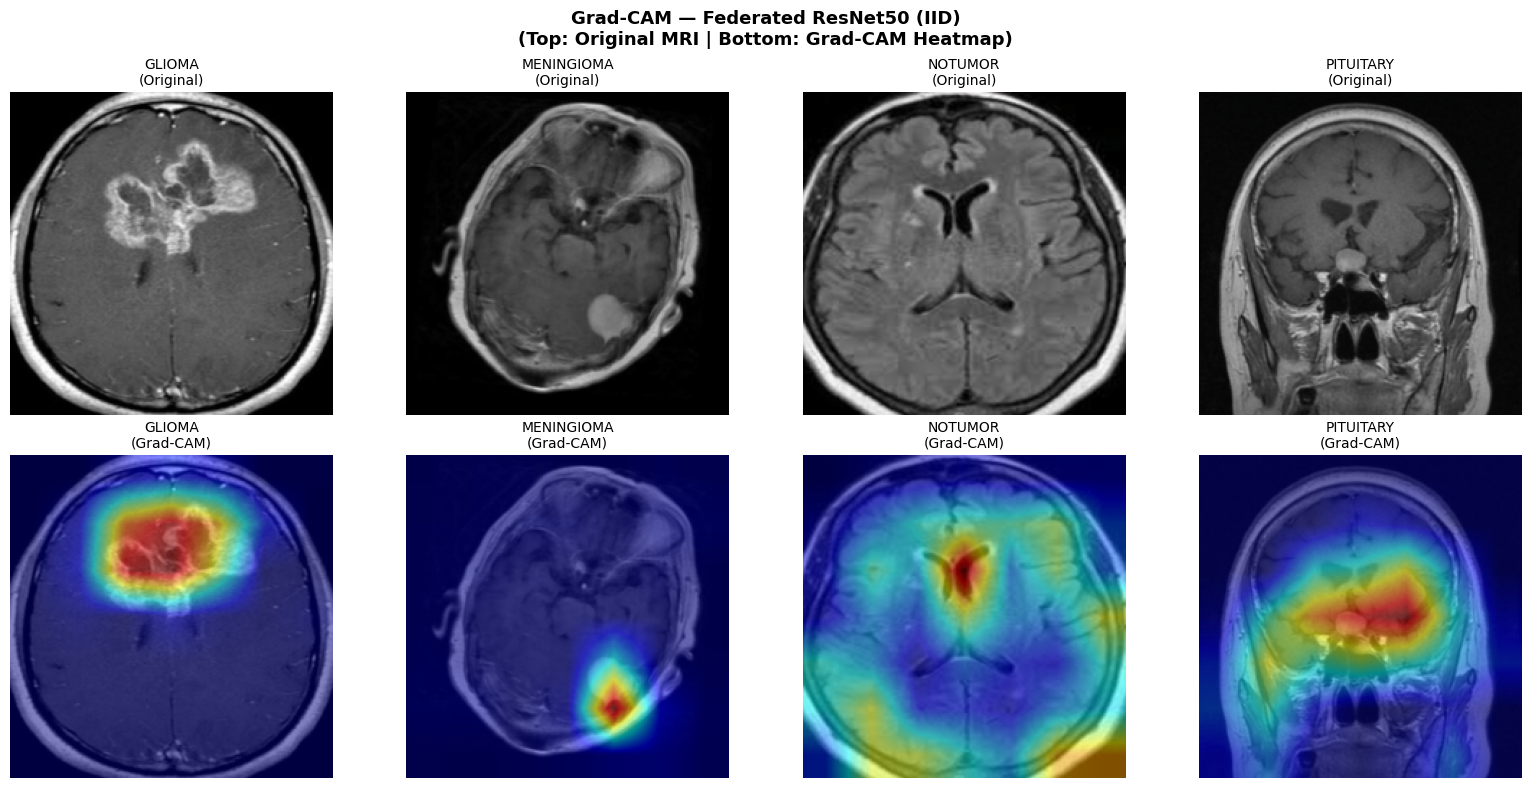

✅ Grad-CAM saved!


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(model=fl_iid_model, target_layers=[fl_iid_model.layer4[-1]])

class_samples = {i: None for i in range(CONFIG['num_classes'])}
for images, labels in test_loader:
    for img, label in zip(images, labels):
        label = label.item()
        if class_samples[label] is None:
            class_samples[label] = img
    if all(v is not None for v in class_samples.values()):
        break

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Grad-CAM — Federated ResNet50 (IID)\n'
             '(Top: Original MRI | Bottom: Grad-CAM Heatmap)',
             fontsize=13, fontweight='bold')

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for idx, (class_idx, img_tensor) in enumerate(class_samples.items()):
    input_tensor  = img_tensor.unsqueeze(0).to(DEVICE)
    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(class_idx)])[0]
    img_np  = np.clip(std * img_tensor.permute(1,2,0).numpy() + mean,
                      0, 1).astype(np.float32)
    cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0][idx].imshow(img_np)
    axes[0][idx].set_title(f'{CONFIG["classes"][class_idx].upper()}\n(Original)', fontsize=10)
    axes[0][idx].axis('off')
    axes[1][idx].imshow(cam_img)
    axes[1][idx].set_title(f'{CONFIG["classes"][class_idx].upper()}\n(Grad-CAM)', fontsize=10)
    axes[1][idx].axis('off')

plt.tight_layout()
plt.savefig('/content/gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM saved!')

---
## Final Summary
| Experiment | Setting | Training Budget |
|---|---|---|
| Centralized | Full data, no privacy | 15 epochs |
| Federated IID | 3 clients, equal split | 5 rounds × 3 epochs = 15 |
| Federated Non-IID | 3 clients, 70/30 split | 5 rounds × 3 epochs = 15 |

### Output Files (Drive: BrainTumor_FL_Results_Final/)
```
├── Models       : 3 × .pth
├── Accuracy     : central + iid + noniid curves
├── Confusion    : 3 × confusion matrix
├── Comparison   : all 3 on same plot
├── Comm Cost    : communication cost curve
└── Grad-CAM     : 4 class heatmaps
```